DATASET UPLOAD AND CHECK

In [1]:
DATASET_PATH = "/content/drive/MyDrive/balanced_dataset"

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.listdir(DATASET_PATH)

['train', 'val', 'test']

In [4]:
#loading csv files
import pandas as pd

train_csv = pd.read_csv(f"{DATASET_PATH}/train/labels.csv")
val_csv = pd.read_csv(f"{DATASET_PATH}/val/labels.csv")
test_csv = pd.read_csv(f"{DATASET_PATH}/test/labels.csv")

print("Train shape:", train_csv.shape)
print("Val shape:", val_csv.shape)
print("Test shape:", test_csv.shape)

Train shape: (8348, 4)
Val shape: (1134, 4)
Test shape: (1042, 4)


In [5]:
#verifying balance
print(train_csv['class'].value_counts())
print(val_csv['class'].value_counts())
print(test_csv['class'].value_counts())

class
0    4174
1    4174
Name: count, dtype: int64
class
0    567
1    567
Name: count, dtype: int64
class
0    521
1    521
Name: count, dtype: int64


In [6]:
#verifying size and mode
from PIL import Image
import random

sample_image_path = f"{DATASET_PATH}/train/images/" + random.choice(train_csv['image_name'].tolist())

img = Image.open(sample_image_path)
print("Image size:", img.size)
print("Image mode:", img.mode)

Image size: (744, 562)
Image mode: L


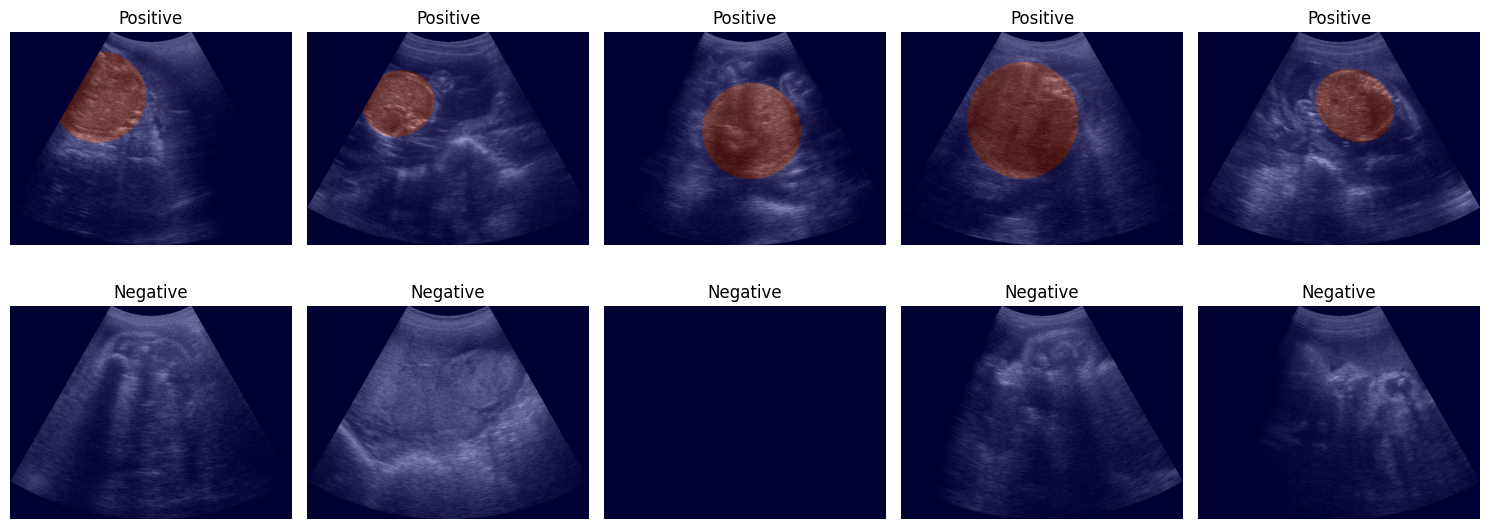

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_random_samples(split="train", n=5):
    csv_file = pd.read_csv(f"{DATASET_PATH}/{split}/labels.csv")
    positive_samples = csv_file[csv_file['class'] == 1].sample(n)
    negative_samples = csv_file[csv_file['class'] == 0].sample(n)

    fig, axes = plt.subplots(2, n, figsize=(15,6))

    for i, row in enumerate(positive_samples.itertuples()):
        img = Image.open(f"{DATASET_PATH}/{split}/images/{row.image_name}")
        mask = Image.open(f"{DATASET_PATH}/{split}/masks/{row.mask_name}")

        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].imshow(mask, cmap='jet', alpha=0.4)
        axes[0, i].set_title("Positive")
        axes[0, i].axis("off")

    for i, row in enumerate(negative_samples.itertuples()):
        img = Image.open(f"{DATASET_PATH}/{split}/images/{row.image_name}")
        mask = Image.open(f"{DATASET_PATH}/{split}/masks/{row.mask_name}")

        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].imshow(mask, cmap='jet', alpha=0.4)
        axes[1, i].set_title("Negative")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

visualize_random_samples("train", 5)

In [8]:
#custom dataset
from PIL import Image
from torch.utils.data import Dataset
import torch

class FetalAbdomenDataset(Dataset):
    def __init__(self, csv_file, image_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.image_dir, row['image_name'])
        label = torch.tensor(row['class'], dtype=torch.float32)

        image = Image.open(img_path).convert("L")

        if self.transform:
            image = self.transform(image)

        return image, label

In [9]:
#aspect ratio preservation transform
import torchvision.transforms as transforms
import torch.nn.functional as F

class PadToSquare:
    def __call__(self, img):
        w, h = img.size
        max_side = max(w, h)

        pad_left = (max_side - w) // 2
        pad_right = max_side - w - pad_left
        pad_top = (max_side - h) // 2
        pad_bottom = max_side - h - pad_top

        padding = (pad_left, pad_top, pad_right, pad_bottom)
        return transforms.functional.pad(img, padding, fill=0)

In [10]:
'''#pixel statistics
from tqdm import tqdm

def compute_mean_std(split="train"):
    csv_file = pd.read_csv(f"{DATASET_PATH}/{split}/labels.csv")
    pixel_sum = 0
    pixel_sq_sum = 0
    num_pixels = 0

    for row in tqdm(csv_file.itertuples(), total=len(csv_file)):
        img = np.array(Image.open(f"{DATASET_PATH}/{split}/images/{row.image_name}")) / 255.0
        pixel_sum += img.sum()
        pixel_sq_sum += (img ** 2).sum()
        num_pixels += img.size

    mean = pixel_sum / num_pixels
    std = np.sqrt(pixel_sq_sum / num_pixels - mean ** 2)

    print("Mean:", mean)
    print("Std:", std)

compute_mean_std("train")

'''

#transformation pipeline
mean = 0.11916620971431377
std = 0.1479186227862317

train_transform = transforms.Compose([
    PadToSquare(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3,1,1)),
    transforms.Normalize(mean=[mean]*3, std=[std]*3)
])

val_transform = transforms.Compose([
    PadToSquare(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3,1,1)),
    transforms.Normalize(mean=[mean]*3, std=[std]*3)
])

In [11]:
from torch.utils.data import DataLoader

DATASET_PATH = "/content/drive/MyDrive/balanced_dataset"

train_dataset = FetalAbdomenDataset(
    csv_file=f"{DATASET_PATH}/train/labels.csv",
    image_dir=f"{DATASET_PATH}/train/images",
    transform=train_transform
)

val_dataset = FetalAbdomenDataset(
    csv_file=f"{DATASET_PATH}/val/labels.csv",
    image_dir=f"{DATASET_PATH}/val/images",
    transform=val_transform
)
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [12]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([16, 3, 224, 224])
torch.Size([16])


In [13]:
torch.cuda.is_available()

True

In [14]:
#loading resnet34 pretrained model
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet34(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 212MB/s]


In [15]:
#replacing final layer for binary classification
num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 1)

In [16]:
#moving model to gpu device
model = model.to(device)

In [17]:
#defining loss function
criterion = nn.BCEWithLogitsLoss()

In [18]:
#defining optimizer
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [19]:
model.to(device)
images.to(device)
labels.to(device)

tensor([0., 0., 0., 1., 0., 0., 1., 1., 1., 1., 0., 1., 0., 1., 0., 1.],
       device='cuda:0')

In [20]:
#quick check
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([16, 1])


In [21]:
!nvidia-smi

Sat Mar  7 06:44:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P0             26W /   70W |     809MiB /  15360MiB |     16%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [22]:
!pip install scikit-learn

In [23]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [45]:
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
import numpy as np

def compute_metrics(y_true, y_pred_prob):

    y_pred = (y_pred_prob > 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)

    auc = roc_auc_score(y_true, y_pred_prob)

    return acc, sensitivity, specificity, auc

In [25]:
def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    running_loss = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(loader.dataset)

    return epoch_loss

In [26]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)

            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)

            running_loss += loss.item() * images.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    val_loss = running_loss / len(loader.dataset)

    all_labels = np.array(all_labels).flatten()
    all_probs = np.array(all_probs).flatten()

    acc, sens, spec, auc = compute_metrics(all_labels, all_probs)

    return val_loss, acc, sens, spec, auc

In [27]:
num_epochs = 10

best_auc = 0

train_losses = []
val_losses = []
accuracies = []
sensitivities = []
specificities = []
aucs = []

for epoch in range(num_epochs):

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )

    val_loss, acc, sens, spec, auc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    # store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    accuracies.append(acc)
    sensitivities.append(sens)
    specificities.append(spec)
    aucs.append(auc)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Sensitivity: {sens:.4f}")
    print(f"Specificity: {spec:.4f}")
    print(f"AUC: {auc:.4f}")
    print()

    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), "best_model1.pth")
        print("Best model saved")

Epoch 1/10
Train Loss: 0.6033
Val Loss: 0.5016
Accuracy: 0.7795
Sensitivity: 0.8571
Specificity: 0.7019
AUC: 0.8602

Best model saved
Epoch 2/10
Train Loss: 0.5033
Val Loss: 0.4578
Accuracy: 0.7945
Sensitivity: 0.8448
Specificity: 0.7443
AUC: 0.8736

Best model saved
Epoch 3/10
Train Loss: 0.4737
Val Loss: 0.4401
Accuracy: 0.8025
Sensitivity: 0.9030
Specificity: 0.7019
AUC: 0.8810

Best model saved
Epoch 4/10
Train Loss: 0.4605
Val Loss: 0.4280
Accuracy: 0.7989
Sensitivity: 0.8131
Specificity: 0.7848
AUC: 0.8852

Best model saved
Epoch 5/10
Train Loss: 0.4525
Val Loss: 0.4190
Accuracy: 0.8157
Sensitivity: 0.8924
Specificity: 0.7390
AUC: 0.8876

Best model saved
Epoch 6/10
Train Loss: 0.4447
Val Loss: 0.4121
Accuracy: 0.8236
Sensitivity: 0.8907
Specificity: 0.7566
AUC: 0.8914

Best model saved
Epoch 7/10
Train Loss: 0.4417
Val Loss: 0.4068
Accuracy: 0.8175
Sensitivity: 0.9012
Specificity: 0.7337
AUC: 0.8953

Best model saved
Epoch 8/10
Train Loss: 0.4296
Val Loss: 0.3985
Accuracy: 0.821

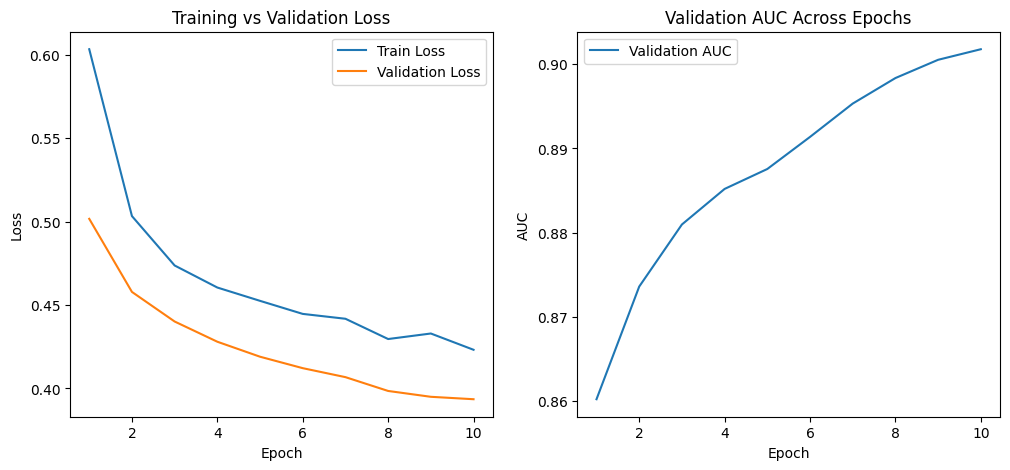

In [28]:

epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, aucs, label="Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Validation AUC Across Epochs")
plt.legend()

plt.show()

In [29]:
import os
os.listdir("/content")

['.config', 'best_model1.pth', 'drive', 'sample_data']

In [30]:
import shutil

source = "/content/best_model1.pth"
destination = "/content/drive/MyDrive/best_model1.pth"

shutil.move(source, destination)

print("Model moved to Google Drive successfully!")

Model moved to Google Drive successfully!


In [31]:
test_dataset = FetalAbdomenDataset(
    csv_file=f"{DATASET_PATH}/test/labels.csv",
    image_dir=f"{DATASET_PATH}/test/images",
    transform=val_transform
)

In [32]:
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

In [34]:
model.load_state_dict(
    torch.load("/content/drive/MyDrive/best_model1.pth")
)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [35]:
from sklearn.metrics import roc_auc_score
import numpy as np

def test_model(model, loader, device):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = torch.sigmoid(outputs)

            all_preds.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds).flatten()
    all_labels = np.array(all_labels).flatten()

    preds_binary = (all_preds > 0.5).astype(int)

    accuracy = (preds_binary == all_labels).mean()

    TP = np.sum((preds_binary == 1) & (all_labels == 1))
    TN = np.sum((preds_binary == 0) & (all_labels == 0))
    FP = np.sum((preds_binary == 1) & (all_labels == 0))
    FN = np.sum((preds_binary == 0) & (all_labels == 1))

    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)

    auc = roc_auc_score(all_labels, all_preds)

    print("Test Results")
    print("Accuracy:", accuracy)
    print("Sensitivity:", sensitivity)
    print("Specificity:", specificity)
    print("AUC:", auc)

    return all_preds, all_labels

In [36]:
test_preds, test_labels = test_model(
    model,
    test_loader,
    device
)

Test Results
Accuracy: 0.791746641074856
Sensitivity: 0.8195777351247601
Specificity: 0.763915547024952
AUC: 0.876153565599891


In [37]:
import numpy as np

all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float()

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs).flatten()
all_preds = np.array(all_preds).flatten()
all_labels = np.array(all_labels).flatten()

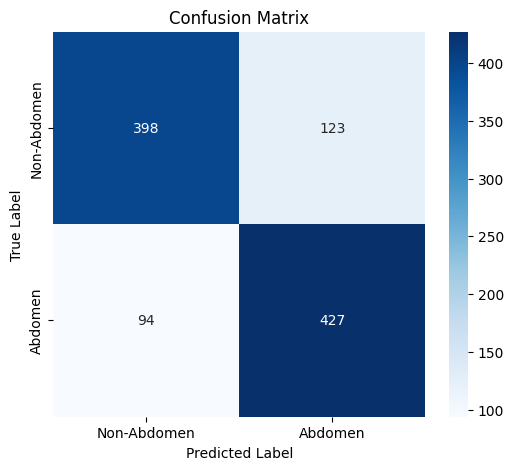

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Abdomen','Abdomen'],
            yticklabels=['Non-Abdomen','Abdomen'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

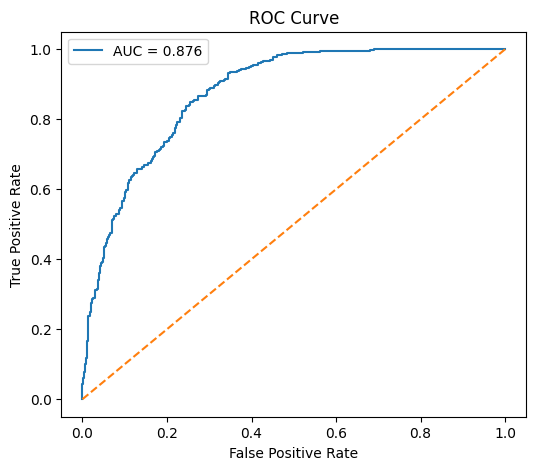

In [39]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

Misclassification Analysis

In [40]:
import random
from PIL import Image

test_csv = pd.read_csv(f"{DATASET_PATH}/test/labels.csv")

misclassified = []

for i in range(len(all_preds)):

    if all_preds[i] != all_labels[i]:
        misclassified.append(i)

print("Total misclassified:", len(misclassified))

Total misclassified: 217


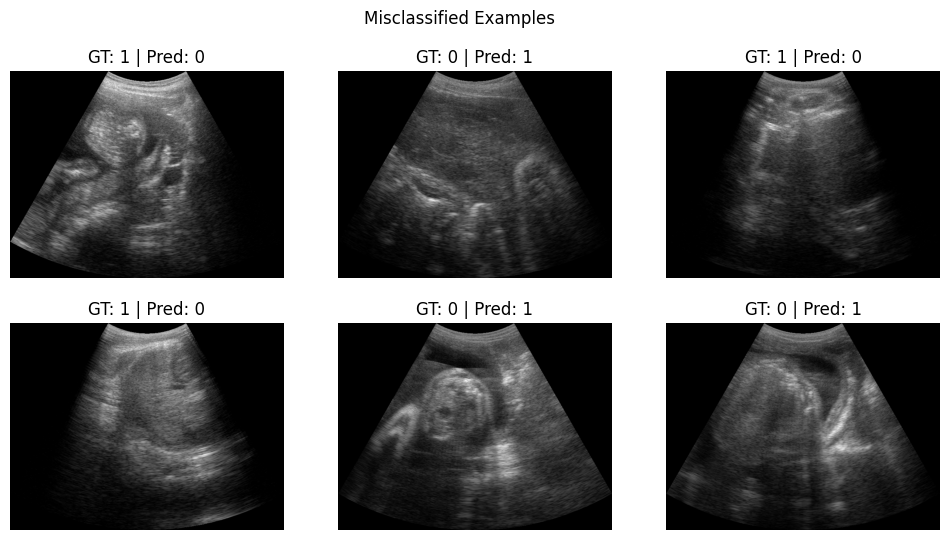

In [41]:
n = 6

samples = random.sample(misclassified, n)

plt.figure(figsize=(12,6))

for i, idx in enumerate(samples):

    row = test_csv.iloc[idx]

    img = Image.open(f"{DATASET_PATH}/test/images/{row.image_name}")

    plt.subplot(2,3,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"GT: {int(all_labels[idx])} | Pred: {int(all_preds[idx])}")
    plt.axis("off")

plt.suptitle("Misclassified Examples")
plt.show()

Classification Analysis

In [42]:
import random
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd

test_csv = pd.read_csv(f"{DATASET_PATH}/test/labels.csv")

correct = []

for i in range(len(all_preds)):

    if all_preds[i] == all_labels[i]:
        correct.append(i)

print("Total correct predictions:", len(correct))

Total correct predictions: 825


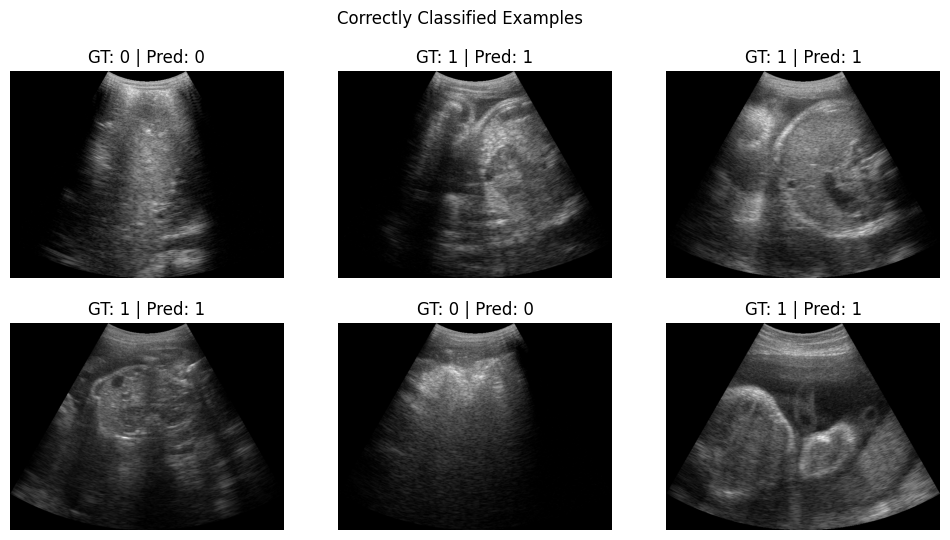

In [44]:
n = 6

samples = random.sample(correct, n)

plt.figure(figsize=(12,6))

for i, idx in enumerate(samples):

    row = test_csv.iloc[idx]

    img = Image.open(f"{DATASET_PATH}/test/images/{row.image_name}")

    plt.subplot(2,3,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(f"GT: {int(all_labels[idx])} | Pred: {int(all_preds[idx])}")
    plt.axis("off")

plt.suptitle("Correctly Classified Examples")

plt.show()

GradCam Implementation

In [52]:

class GradCAM:

    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image):

        output = self.model(input_image)

        self.model.zero_grad()

        output.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = torch.mean(gradients, dim=(1,2))

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(input_image.device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)

        cam = cam.cpu().detach().numpy()

        cam = cv2.resize(cam, (224,224))

        cam = (cam - cam.min()) / (cam.max() - cam.min())

        return cam

In [53]:
grad_cam = GradCAM(model, model.layer4)

In [54]:
import random

idx = random.randint(0, len(test_dataset)-1)

image, label = test_dataset[idx]

input_tensor = image.unsqueeze(0).to(device)

In [56]:
original_requires_grad_states = {}
for name, param in model.named_parameters():
    original_requires_grad_states[name] = param.requires_grad
    param.requires_grad = True # Temporarily enable gradients for all parameters

input_tensor.requires_grad_(True)

heatmap = grad_cam.generate(input_tensor)

for name, param in model.named_parameters():
    param.requires_grad = original_requires_grad_states[name]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [58]:
img = image.permute(1,2,0).cpu().numpy()

img = (img - img.min()) / (img.max() - img.min())

heatmap_color = cv2.applyColorMap(
    np.uint8(255 * heatmap),
    cv2.COLORMAP_JET
)

heatmap_color = heatmap_color / 255

overlay = heatmap_color * 0.4 + img

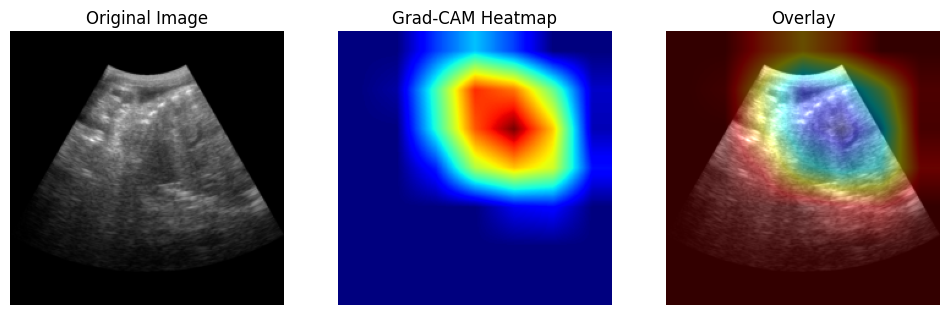

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.show()

In [60]:
tp, tn, fp, fn = [], [], [], []

for i in range(len(all_preds)):

    pred = int(all_preds[i])
    label = int(all_labels[i])

    if pred == 1 and label == 1:
        tp.append(i)

    elif pred == 0 and label == 0:
        tn.append(i)

    elif pred == 1 and label == 0:
        fp.append(i)

    elif pred == 0 and label == 1:
        fn.append(i)

print("TP:", len(tp))
print("TN:", len(tn))
print("FP:", len(fp))
print("FN:", len(fn))

TP: 427
TN: 398
FP: 123
FN: 94


In [61]:
def generate_gradcam_visual(image_tensor):

    input_tensor = image_tensor.unsqueeze(0).to(device)

    heatmap = grad_cam.generate(input_tensor)

    img = image_tensor.permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())

    heatmap_color = cv2.applyColorMap(
        np.uint8(255 * heatmap),
        cv2.COLORMAP_JET
    ) / 255

    overlay = heatmap_color * 0.4 + img

    return img, heatmap, overlay

In [62]:
import random

samples = []

samples += random.sample(tp, min(3, len(tp)))
samples += random.sample(tn, min(3, len(tn)))
samples += random.sample(fp, min(2, len(fp)))
samples += random.sample(fn, min(2, len(fn)))

/tmp/ipykernel_2098/4286439818.py:44: RuntimeWarning: invalid value encountered in divide
  cam = (cam - cam.min()) / (cam.max() - cam.min())
/tmp/ipykernel_2098/2938360682.py:11: RuntimeWarning: invalid value encountered in cast
  np.uint8(255 * heatmap),


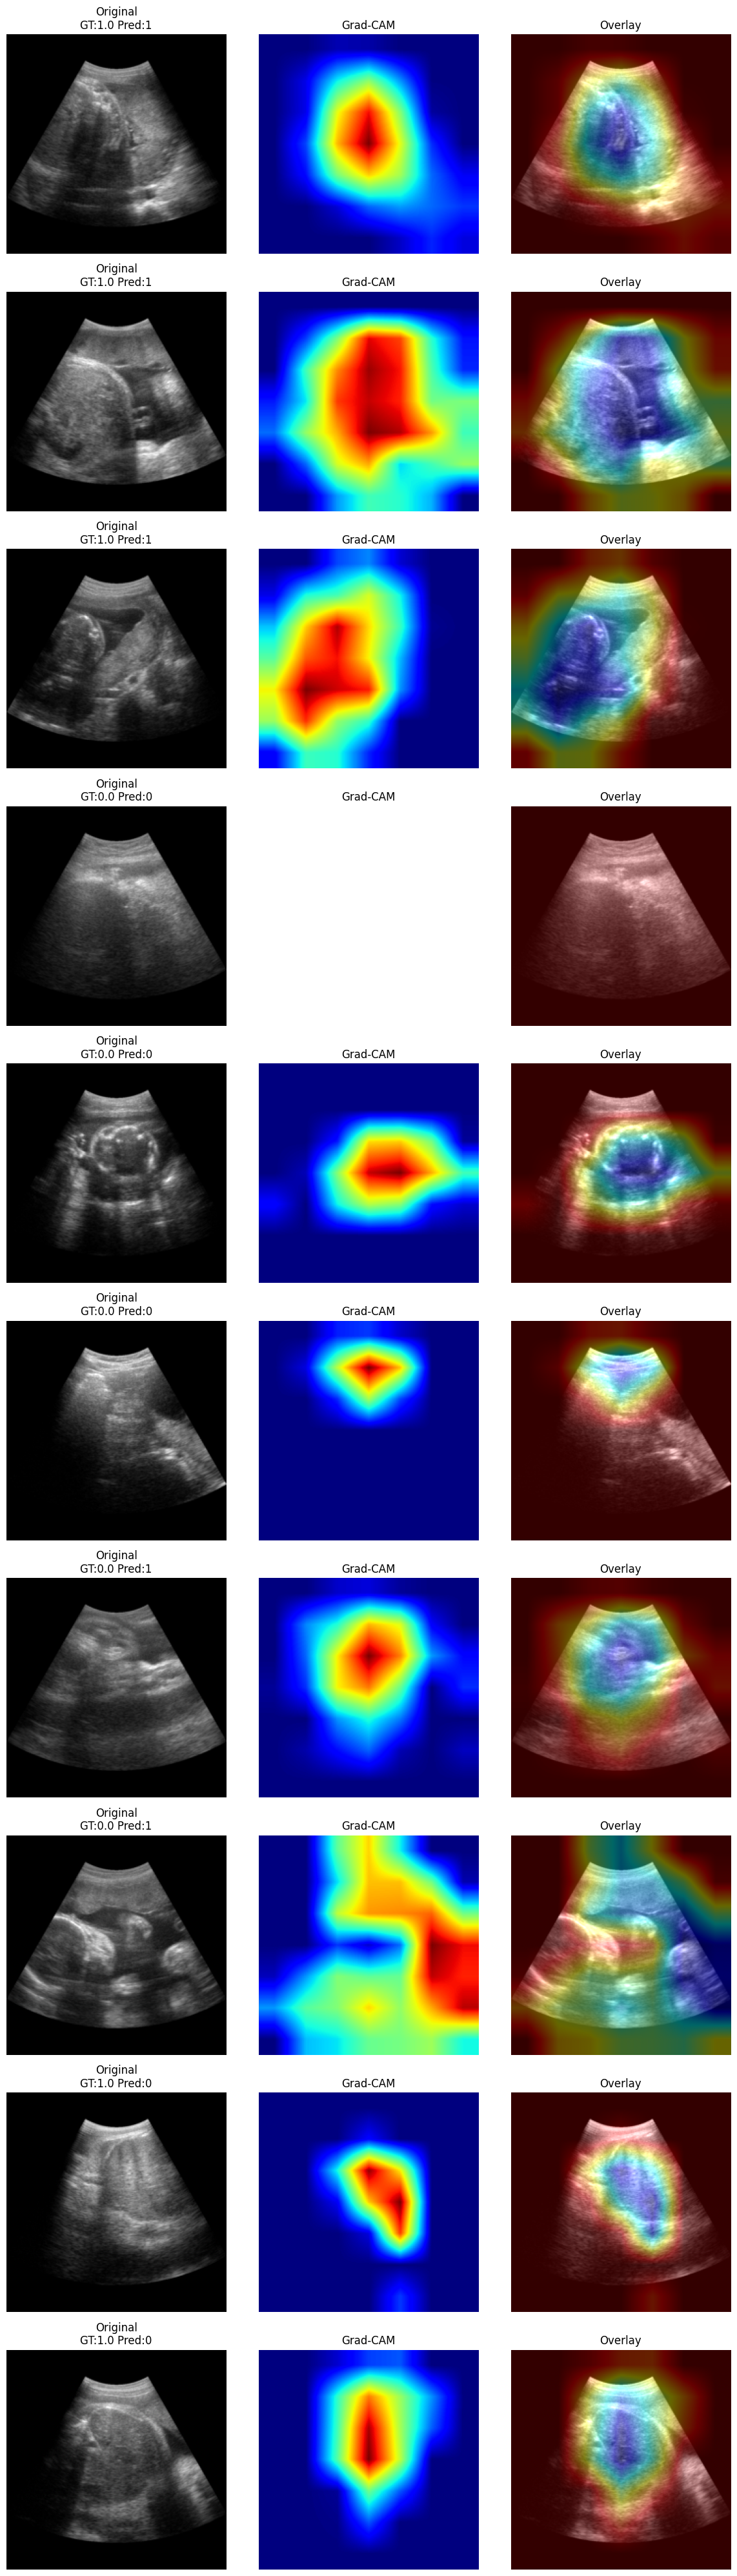

In [63]:
plt.figure(figsize=(12, 4 * len(samples)))

for i, idx in enumerate(samples):

    image, label = test_dataset[idx]

    img, heatmap, overlay = generate_gradcam_visual(image)

    pred = int(all_preds[idx])

    # original
    plt.subplot(len(samples), 3, i*3 + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Original\nGT:{label} Pred:{pred}")
    plt.axis("off")

    # heatmap
    plt.subplot(len(samples), 3, i*3 + 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Grad-CAM")
    plt.axis("off")

    # overlay
    plt.subplot(len(samples), 3, i*3 + 3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()